In [86]:
# Stuff to import + seed generator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson
from scipy.optimize import brentq, minimize_scalar
from mp1lib import bsc, packet_errors, tv_distance, attempts_until_clean, run_step7_experiments, calculate_step7_spread, calculate_envelope, find_trials_within_one_percent
    




#Seed Generator
SEED = 1234 #we didn't have a group number so we are using 1234 as the seed
rng = np.random.default_rng(SEED)
rng_step = rng.spawn(1)[0]
rng_step2 = rng.spawn(1)[0]
rng_step3 = rng.spawn(1)[0]
rng_step4 = rng.spawn(1)[0]
rng_step5 = rng.spawn(1)[0]
rng_step6 = rng.spawn(1)[0]
rng_step7 = rng.spawn(1)[0]
rng_step8 = rng.spawn(1)[0]
rng_bonus = rng.spawn(1)[0]

Total simulated packets: 1,000,000
Total exact probability: 1.000000
Total simulated probability: 1.000000


,Error Pattern,# occurrences (sim),Prob (Calc),Prob (Sim),Difference (%)
0,0000,656206,0.6561,0.656206,1.615607e-02
1,0001,72926,0.0729,0.072926,3.566529e-02
2,0010,73018,0.0729,0.073018,1.618656e-01
3,0011,8132,0.0081,0.008132,3.950617e-01
4,0100,72571,0.0729,0.072571,-4.513032e-01
5,0101,8149,0.0081,0.008149,6.049383e-01
6,0110,7947,0.0081,0.007947,-1.888889e+00
7,0111,845,0.0009,0.000845,-6.111111e+00
8,1000,72917,0.0729,0.072917,2.331962e-02
9,1001,8147,0.0081,0.008147,5.802469e-01


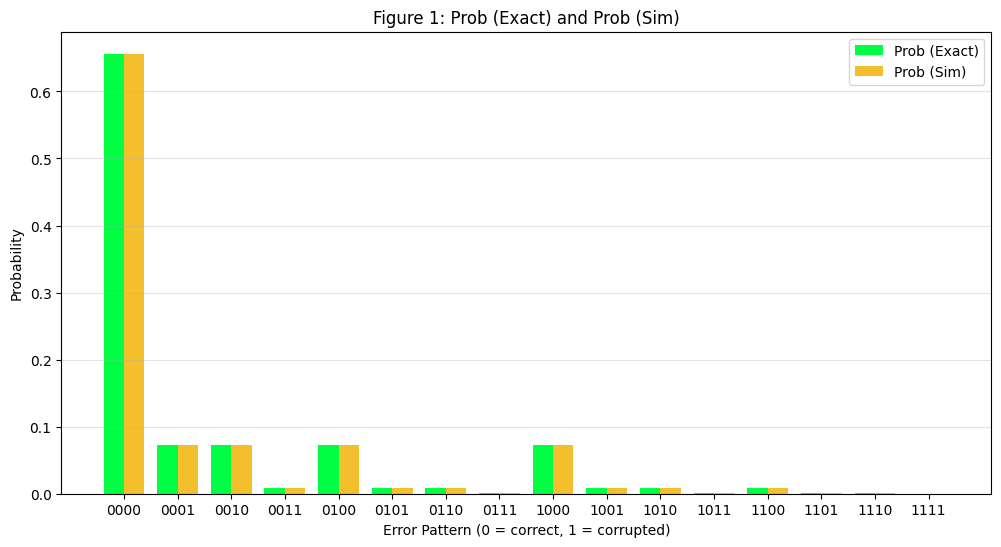

{'P(A)': np.float64(0.189718),
 'P(B)': np.float64(0.048736),
 'P(C)': np.float64(0.100085),
 'P(A and B)': np.float64(0.040604),
 'P(A and C)': np.float64(0.019027),
 'P(B and C)': np.float64(0.024428),
 'P(A and B and C)': np.float64(0.016296),
 'P(A or B or C)': np.float64(0.270776)}

In [87]:
#STEP 1 - THE SAMPLE SPACE AND THE AXIOMS

N = 10**6 #1 million 4-bit packets
p = 0.1 #error probability

bits = np.zeros((N, 4), dtype=int) #every packet starts with four correct bits

#bsc changes some 0s into 1s according to p value and the random number generator
packets = bsc(bits, p, rng_step) #bsc func in mp1lib.py

#count each simulated 4-bit error pattern.
pattern_numbers = packets @ np.array([8, 4, 2, 1])
counts = np.bincount(pattern_numbers, minlength=16)
patterns = [format(i, "04b") for i in range(16)]

#Calculated probability:(1-p)^(correct bits) * p^(corrupted bits) ex. (0.9)^4*(0.1)^0 = 0.6561 for 0000
number_of_errors = np.array([pattern.count("1") for pattern in patterns])
prob_exact = (1 - p) ** (4 - number_of_errors) * p ** number_of_errors
prob_sim = counts / N
percent_difference = (prob_sim - prob_exact) / prob_exact * 100


print(f"Total simulated packets: {counts.sum():,}") #total should be 1 million
print(f"Total exact probability: {prob_exact.sum():.6f}") #should add up to 1
print(f"Total simulated probability: {prob_sim.sum():.6f}") #should add up to 1

section1_table = pd.DataFrame({ #creates table data
    "Error Pattern": patterns,
    "# occurrences (sim)": counts,
    "Prob (Calc)": prob_exact,
    "Prob (Sim)": prob_sim,
    "Difference (%)": percent_difference,
})

display(section1_table) #prints table

x = np.arange(len(patterns)) #creates graph of all patterns and their probabilities
bar_width = 0.38
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width / 2, prob_exact, bar_width, label="Prob (Exact)", color="#00ff44")
plt.bar(x + bar_width / 2, prob_sim, bar_width, label="Prob (Sim)", color="#f4bf2d")
plt.xticks(x, patterns)
plt.xlabel("Error Pattern (0 = correct, 1 = corrupted)")
plt.ylabel("Probability")
plt.title("Figure 1: Prob (Exact) and Prob (Sim)")
plt.grid(axis="y", alpha=0.35)
plt.legend()
plt.show()


A = np.any(packets[:, 0:2] == 1, axis=1) #prob. of an error in the first two bits
B = np.sum(packets, axis=1) == 2 #prob. of exactly two errors in the packet
C = packets[:, 3] == 1 #prob. of an error in the last bit


empirical = {
    "P(A)": np.mean(A), #expected output 0.19
    "P(B)": np.mean(B), #expected output 0.0486
    "P(C)": np.mean(C), #expected output 0.1
    "P(A and B)": np.mean(A & B),
    "P(A and C)": np.mean(A & C),
    "P(B and C)": np.mean(B & C),
    "P(A and B and C)": np.mean(A & B & C),
    "P(A or B or C)": np.mean(A | B | C), #expected output 0.2710
}

empirical

^ Explanation for Figure 1 (Pictured above): <br>
The graph shows that the simulated probs closely match the calculated probs, <br>
which is expected since the # of packets simulated is very large at 1 million packets. <br>

Bayes' Rule is used to find the probability that an error occurred given that a flag was raised

$$
P(E \mid F)=\frac{P(F \mid E)P(E)}{P(F)}
$$

The given probabilities are:

$$
P(F \mid E)=0.95
\qquad
P(F \mid \neg E)=0.02
$$

The prior probability of an error is

$$
P(E)=p
\qquad
P(\neg E)=1-p
$$

The total probability of a flag is

$$
P(F)=0.95p+0.02(1-p)
$$

The probability that a flagged bit truly contains an error is

$$
P(E \mid F)
=
\frac{0.95p}{0.95p+0.02(1-p)}
$$

p = 0.1: posterior = 0.840708
p = 0.01: posterior = 0.324232
p = 0.001: posterior = 0.045389


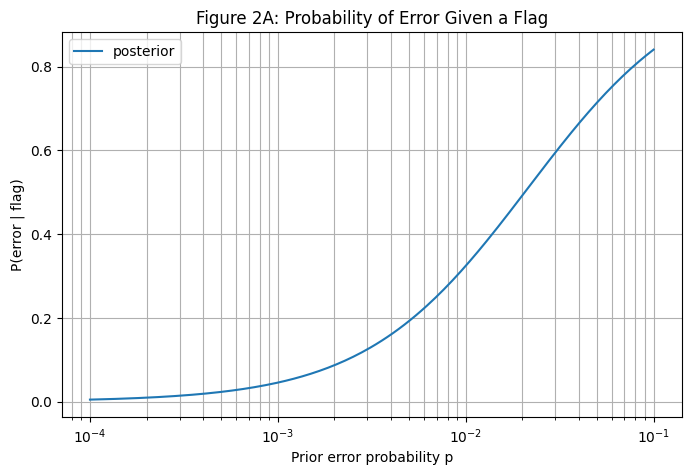

Crossover p = 0.020619
# flags: 391,740
# true errors flagged: 196,106
posterior: 0.500000
Monte Carlo estimate: 0.500602
Std error: 0.000799
Difference: 0.000602


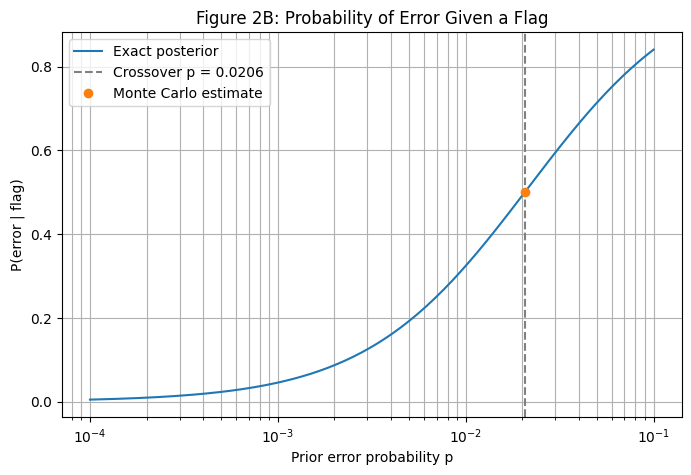

In [88]:
# STEP 2 - CONDITIONAL PROBABILITY AND BAYES

def posterior(p):
    return (0.95 * p) / (0.95 * p + 0.02 * (1 - p))

for p in [0.1, 0.01, 0.001]: # prints the posterior for p = 0.1, 0.01, and 0.001
    print(f"p = {p}: posterior = {posterior(p):.6f}")

p_values = np.logspace(-4, -1, 200) #creates 200 p values from 10^-4 to 10^-1 (log curve)
posterior_values = posterior(p_values)

#plots log curve
plt.figure(figsize=(8, 5))
plt.plot(p_values, posterior_values, label="posterior")
plt.xscale("log")
plt.xlabel("Prior error probability p")
plt.ylabel("P(error | flag)")
plt.title("Figure 2A: Probability of Error Given a Flag")
plt.grid(True, which="both")
plt.legend()
plt.show()


#finds point where posterior=0.5.
p_cross = 0.02 / (0.95 + 0.02)
print(f"Crossover p = {p_cross:.6f}")

#simulates 10 million bits at the crossover point
rng_step2 = rng.spawn(1)[0]
N = 10**7

#gives error status based on crossover prob
errors = rng_step2.random(N) < p_cross

# The circuit flags an error 95% of the time if it is wrong,
# and flags a correct bit 2% of the time.
flag_probability = np.where(errors, 0.95, 0.02)
flags = rng_step2.random(N) < flag_probability

# Count all flags and flags that were truly errors.
number_of_flags = np.sum(flags)
number_flagged_and_in_error = np.sum(flags & errors)

# Estimated posterior = flagged errors / all flags.
posterior_estimate = number_flagged_and_in_error / number_of_flags

# Calculate uncertainty in the simulation estimate.
standard_error = np.sqrt(
    posterior_estimate * (1 - posterior_estimate) / number_of_flags
)
exact_posterior = posterior(p_cross)
difference = abs(posterior_estimate - exact_posterior)

print(f"# flags: {number_of_flags:,}")
print(f"# true errors flagged: {number_flagged_and_in_error:,}")
print(f"posterior: {exact_posterior:.6f}")
print(f"Monte Carlo estimate: {posterior_estimate:.6f}")
print(f"Std error: {standard_error:.6f}")
print(f"Difference: {difference:.6f}")

#plots second curve with line of crossover point
plt.figure(figsize=(8, 5))
plt.plot(p_values, posterior_values, label="Exact posterior")
plt.errorbar(
    p_cross, posterior_estimate,
    fmt="o", capsize=5, label="Monte Carlo estimate"
)
plt.axvline(
    p_cross, linestyle="--", color="gray",
    label=f"Crossover p = {p_cross:.4f}"
)
plt.xscale("log")
plt.xlabel("Prior error probability p")
plt.ylabel("P(error | flag)")
plt.title("Figure 2B: Probability of Error Given a Flag")
plt.grid(True, which="both")
plt.legend()
plt.show()

^ Explanation for Fig. 2A: The graph shows that the posterior probability of an error given a flag is very low for a good link. <br>
When the p value is very small, a flagged bit is unlikely to be a real error because of the number of false positives, however as <br>
p increases, the probability that the flagged bit is actually containing an error also increases. <br> <br>
^ Explanation for Fig. 2B: the graph shows that the Monte Carlo estimate is very close to the exact posterior that was calculated. <br>
This also shows how as the p value gets larget, the probability that a flagged bit contains a real error also increases. <br>

The reason why a 95% accurate circuit means nothing on a good link is because <br>
the system will always flag a lot of bits as errors even when they're not supposed to be errors. <br>
For example in our scenario, there were 391,066 flags, but only 195,015 were actually errors. <br>
So there were an almost 200,000 extra flags that were false positives, which would need to be sorted out. <br>

In [89]:
#STEP 3 - INDEPENDENCE

rng_step3 = rng.spawn(1)[0]
N3 = 10**6

#creates 2 coin flips for each trial, 0 = tails, 1 = heads
coins = rng_step3.integers(0, 2, size=(N3, 2))

#3 different outcomes
E1 = coins[:, 0] == 1 #first coin is heads
E2 = coins[:, 1] == 1 #second coin is heads
E3 = coins[:, 0] == coins[:, 1] #coins match

#finds the simulated probabilities of each event
p_E1 = np.mean(E1)
p_E2 = np.mean(E2)
p_E3 = np.mean(E3)

#table of the basic probability comparisons.
basic_table = pd.DataFrame({
    "Event": ["P(E1)", "P(E2)", "P(E3)", "P(E1 and E2)"],
    "Calculated": [0.5, 0.5, 0.5, 0.25],
    "Simulated": [p_E1, p_E2, p_E3, np.mean(E1 & E2)],
})
display(basic_table.round(6))

#pairwise independence means P(A and B) = P(A)P(B).
pairwise_table = pd.DataFrame({
    "Pair": ["E1, E2", "E1, E3", "E2, E3"],
    "Product P(A)P(B)": [p_E1 * p_E2, p_E1 * p_E3, p_E2 * p_E3],
    "Joint P(A and B)": [np.mean(E1 & E2), np.mean(E1 & E3), np.mean(E2 & E3)],
})
print("\nPairwise independence comparisons:")
display(pairwise_table.round(6))

#mutual independence would require the triple product to equal the
#probability of all three events happening together.
triple_product = p_E1 * p_E2 * p_E3
triple_joint = np.mean(E1 & E2 & E3)
print("Comparison:")
print(f"P(E1)P(E2)P(E3) = {triple_product:.6f}")
print(f"P(E1 and E2 and E3) = {triple_joint:.6f}")

#the transmitted bit is equally likely to be 0 or 1.
sent = rng_step3.integers(0, 2, size=N3)

#each receiver independently flips the transmitted bit with its own error probability.
receiver1 = sent ^ (rng_step3.random(N3) < 0.1)
receiver2 = sent ^ (rng_step3.random(N3) < 0.3)

#calculates Pearson correlation and an approximate std error.
def correlation_and_se(x, y):
    correlation = np.corrcoef(x, y)[0, 1]
    standard_error = np.sqrt((1 - correlation**2) / (len(x) - 2))
    return correlation, standard_error


corr_all, se_all = correlation_and_se(receiver1, receiver2) #correlation using every transmission
corr_sent0, se_sent0 = correlation_and_se(receiver1[sent == 0], receiver2[sent == 0]) #correlation when sent bit = 0
corr_sent1, se_sent1 = correlation_and_se(receiver1[sent == 1], receiver2[sent == 1]) #correlation when sent bit = 1

#correlation results table
correlation_table = pd.DataFrame({
    "Condition": ["All transmissions", "Sent bit = 0", "Sent bit = 1"],
    "Correlation": [corr_all, corr_sent0, corr_sent1],
    "Standard error": [se_all, se_sent0, se_sent1],
})
display(correlation_table.round(6))

,Event,Calculated,Simulated
0,P(E1),0.50,0.499455
1,P(E2),0.50,0.499966
2,P(E3),0.50,0.500431
3,P(E1 and E2),0.25,0.249926



Pairwise independence comparisons:


,Pair,Product P(A)P(B),Joint P(A and B)
0,"E1, E2",0.249711,0.249926
1,"E1, E3",0.249943,0.249926
2,"E2, E3",0.250198,0.249926


Comparison:
P(E1)P(E2)P(E3) = 0.124963
P(E1 and E2 and E3) = 0.249926


,Condition,Correlation,Standard error
0,All transmissions,0.320618,0.000947
1,Sent bit = 0,0.001001,0.001413
2,Sent bit = 1,-0.000000,0.001415


When a system fuses 2 sensor readings assuming they are independent when they are actually sharing a common cause, <br>
it can make an error appear to be more certain than it is supposed to be, which can create wrong conclusions. <br>
For example, aircraft need several pitot tubes to meausre airspeed, because if the readings all come from the same pitot tube, <br>
a small blockage or a frozen pitot tube can cause the aircraft to read its speed, angle of attack, and other values incorrectly <br>
and it can assume that the values are coming independently, when in fact they have a common cause of failure.

Why Binomial: the number of errors in a packet is the sum of 1000 bit-error indicators.
If the bits are corrupted INDEPENDENTLY, each with the SAME probability p,
that sum of i.i.d. Bernoulli(p) variables is Binomial(1000, p).
Closed forms: mean = n*p, variance = n*p*(1-p), P(clean) = (1-p)^n
At n = 1000, p = 0.005: mean = 5, variance = 4.975

packet_errors tests passed



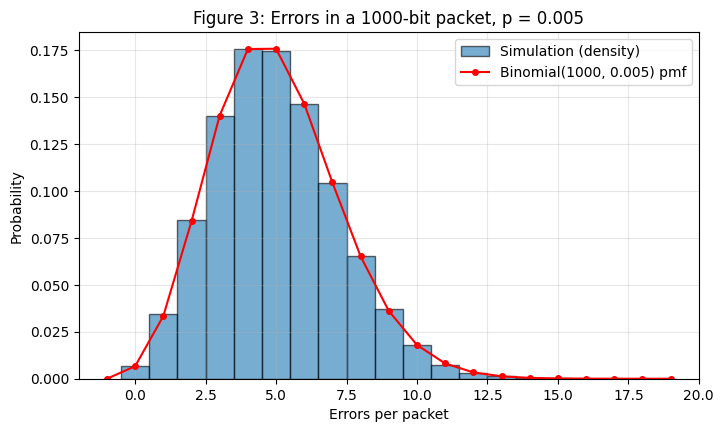

Figure 3 interpretation: the density histogram follows the exact Binomial pmf over the whole range.
Both peak at 4 to 5 errors (pmf about 0.175) and have almost no mass beyond about 15 errors.

mean:     sim 4.9941  theory 5.0000  diff -0.0059  SE 0.0071  (-0.84 SE)
variance: sim 4.9856  theory 4.9750  diff +0.0106  SE 0.0222  (+0.48 SE)



,p,Exact (1-p)^1000,Empirical,Diff,Std error,Diff / SE
0,0.0050,0.006654,0.00715,0.000496,0.000257,1.929383
1,0.0010,0.367695,0.36803,0.000335,0.001525,0.219425
2,0.0001,0.904833,0.90481,-0.000023,0.000928,-0.024671


At p = 0.005 only 0.67% of packets are clean, so about 150 transmissions
are needed per delivered packet at that error rate.


In [90]:
#STEP 4 - BERNOULLI TRIALS AND THE BINOMIAL

print("Why Binomial: the number of errors in a packet is the sum of 1000 bit-error indicators.")
print("If the bits are corrupted INDEPENDENTLY, each with the SAME probability p,")
print("that sum of i.i.d. Bernoulli(p) variables is Binomial(1000, p).")
print("Closed forms: mean = n*p, variance = n*p*(1-p), P(clean) = (1-p)^n")
print("At n = 1000, p = 0.005: mean = 5, variance = 4.975\n")

#hand-checkable test of packet_errors: p = 0 gives no errors, p = 1 gives every bit in error
assert (packet_errors(4, 10, 0.0, rng_step4) == 0).all()
assert (packet_errors(4, 10, 1.0, rng_step4) == 10).all()
print("packet_errors tests passed\n")

n4, p4, N4 = 1000, 0.005, 10**5 #1000-bit packets, p = 0.005, 100,000 packets
x4 = packet_errors(N4, n4, p4, rng_step4) #number of errors in each packet

#Figure 3: density histogram with the exact Binomial pmf overlaid
k4 = np.arange(x4.min() - 1, x4.max() + 2)
plt.figure(figsize=(8, 4.5))
plt.hist(x4, bins=np.arange(x4.min() - 0.5, x4.max() + 1.5, 1), density=True,
         alpha=0.6, edgecolor="k", label="Simulation (density)")
plt.plot(k4, binom.pmf(k4, n4, p4), "ro-", ms=4, label="Binomial(1000, 0.005) pmf")
plt.xlabel("Errors per packet")
plt.ylabel("Probability")
plt.title("Figure 3: Errors in a 1000-bit packet, p = 0.005")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Figure 3 interpretation: the density histogram follows the exact Binomial pmf over the whole range.")
print("Both peak at 4 to 5 errors (pmf about 0.175) and have almost no mass beyond about 15 errors.\n")

#sample mean and variance vs closed forms
mean_s, var_s = x4.mean(), x4.var(ddof=1)
mean_t, var_t = n4 * p4, n4 * p4 * (1 - p4)
se_mean = np.sqrt(var_t / N4)
se_var = var_t * np.sqrt(2 / (N4 - 1)) #normal-theory approximation

print(f"mean:     sim {mean_s:.4f}  theory {mean_t:.4f}  diff {mean_s - mean_t:+.4f}  SE {se_mean:.4f}  ({(mean_s - mean_t) / se_mean:+.2f} SE)")
print(f"variance: sim {var_s:.4f}  theory {var_t:.4f}  diff {var_s - var_t:+.4f}  SE {se_var:.4f}  ({(var_s - var_t) / se_var:+.2f} SE)\n")

#probability of a clean packet (zero errors), exact vs empirical
rows = []
for pp in [0.005, 0.001, 0.0001]:
    xs = packet_errors(N4, n4, pp, rng_step4)
    empirical_clean = np.mean(xs == 0)
    exact_clean = (1 - pp) ** n4 #same as binom.pmf(0, n4, pp)
    se = np.sqrt(exact_clean * (1 - exact_clean) / N4)
    rows.append([pp, exact_clean, empirical_clean, empirical_clean - exact_clean, se, (empirical_clean - exact_clean) / se])

step4_table = pd.DataFrame(rows, columns=["p", "Exact (1-p)^1000", "Empirical", "Diff", "Std error", "Diff / SE"])
display(step4_table)

print(f"At p = 0.005 only {(1 - 0.005) ** n4:.2%} of packets are clean, so about {1 / (1 - 0.005) ** n4:.0f} transmissions")
print("are needed per delivered packet at that error rate.")

Total variation distance: TV(P, Q) = 0.5 * sum over k of |P(k) - Q(k)|
Le Cam bound in the same convention: TV(Bin(n, p), Poisson(np)) <= n * p^2
Both pmfs are truncated to 0..K with K = ceil(lambda + 20*sqrt(lambda) + 20), lambda = n*p

tv_distance tests passed



,p,lambda = np,K,TV distance,Poisson tail > K,Le Cam n p^2
0,0.5000,500.0,968,0.166057,4.572865e-77,250.00000
1,0.0500,50.0,212,0.012446,1.895351e-65,2.50000
2,0.0050,5.0,70,0.001228,3.605448e-55,0.02500
3,0.0010,1.0,41,0.000276,2.680655e-52,0.00100
4,0.0005,0.5,35,0.000114,2.405163e-53,0.00025


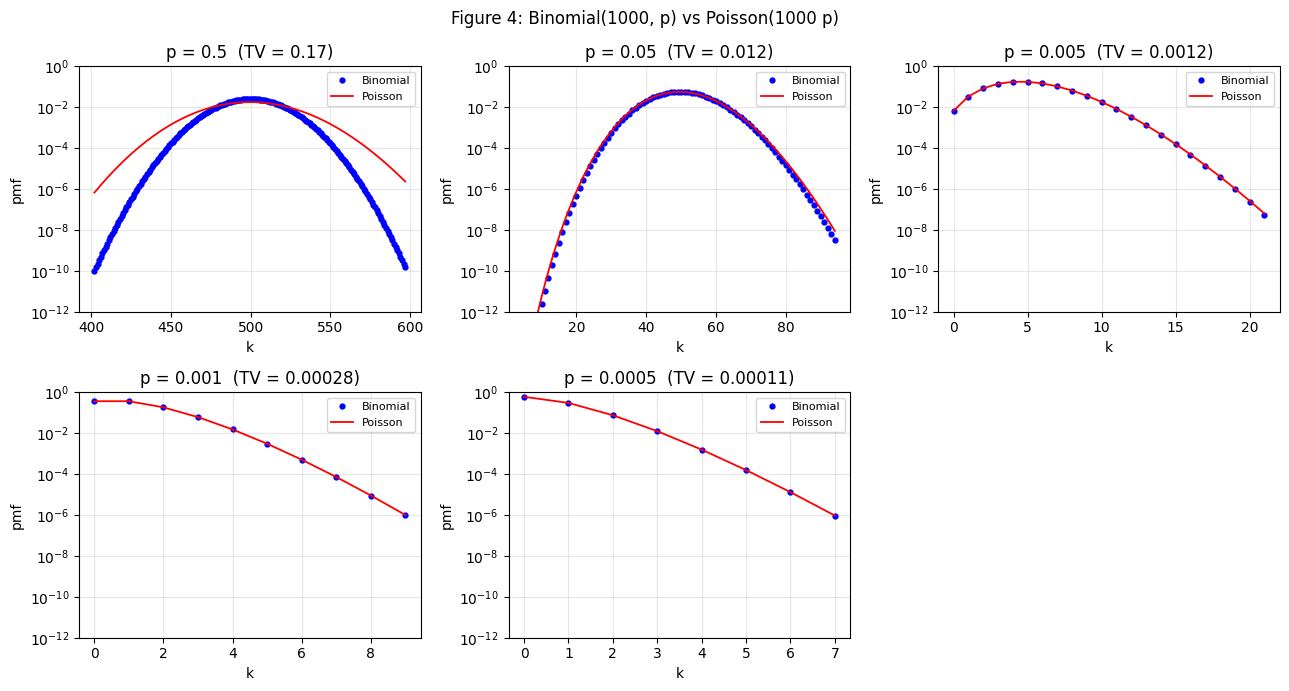

Figure 4 interpretation: for p <= 0.005 the two pmfs are visually indistinguishable, including the tails.
At p = 0.05 the Poisson is slightly too wide (variance lambda vs lambda*(1-p)).
At p = 0.5 the mismatch is obvious: Poisson(500) has std about 22.4 while the Binomial has about 15.8.
TV strictly increasing on [0.001, 0.1]: True
Bisection: largest p with TV < 0.01  ->  p = 0.04  (TV there = 0.010000)
Le Cam: n p^2 = 0.01  ->  p = 0.0032
Bisection answer is ABOVE the Le Cam value (ratio 12.8x)
Why: n*p^2 is an UPPER bound on TV, so the true distance can only reach 0.01 at a p at least as large
as where the bound reaches 0.01.

When is Poisson trustworthy? When n is large, p is small, and n*p^2 << 1 (that is, p << 1/sqrt(n)).
The mean n*p can be any moderate size. Then the Binomial variance n*p*(1-p) is close to the Poisson
variance n*p, and Le Cam guarantees a small TV.



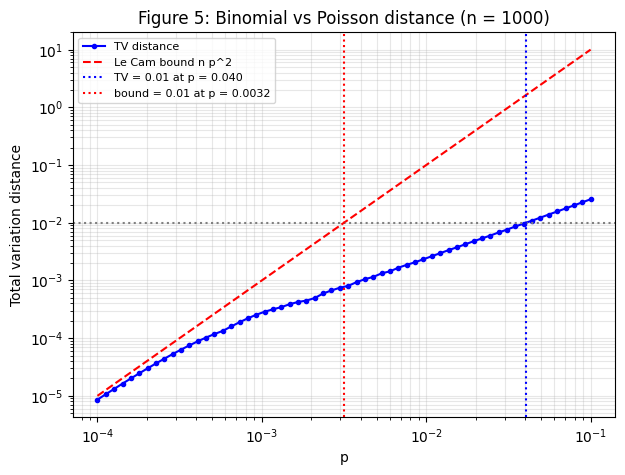

Figure 5 interpretation: on log-log axes the true TV is nearly a straight line of slope about 2,
running roughly an order of magnitude below the Le Cam line (at p = 0.005: TV = 0.0012 vs bound 0.025).
The bound is valid but loose. For large p the bound exceeds 1 and says nothing, since TV can never exceed 1.


In [91]:
# STEP 5 - THE POISSON APPROXIMATION

print("Total variation distance: TV(P, Q) = 0.5 * sum over k of |P(k) - Q(k)|")
print("Le Cam bound in the same convention: TV(Bin(n, p), Poisson(np)) <= n * p^2")
print("Both pmfs are truncated to 0..K with K = ceil(lambda + 20*sqrt(lambda) + 20), lambda = n*p\n")

#tv_distance hand-checks: identical pmfs give exactly 0, disjoint support gives exactly 1
a5 = np.array([0.2, 0.3, 0.5])
assert tv_distance(a5, a5) == 0.0
assert tv_distance(np.array([1.0, 0.0, 0.0]), np.array([0.0, 0.0, 1.0])) == 1.0
print("tv_distance tests passed\n")

def tv_bin_poisson(n, p):
    #TV between Bin(n, p) and Poisson(np), both truncated to 0..K. Returns (TV, K, leftover Poisson tail).
    lam = n * p
    K = int(np.ceil(lam + 20 * np.sqrt(lam) + 20))
    k = np.arange(K + 1)
    tail = poisson.sf(K, lam) #P(Poisson > K)
    return tv_distance(binom.pmf(k, n, p), poisson.pmf(k, lam)), K, tail

n5 = 1000
p_list = [0.5, 0.05, 0.005, 0.001, 0.0005]

rows = []
for pp in p_list:
    d, K, tail = tv_bin_poisson(n5, pp)
    rows.append([pp, n5 * pp, K, d, tail, n5 * pp ** 2])

step5_table = pd.DataFrame(rows, columns=["p", "lambda = np", "K", "TV distance", "Poisson tail > K", "Le Cam n p^2"])
display(step5_table)
assert (step5_table["Poisson tail > K"] < 1e-12).all() #truncation did not matter

#Figure 4: Binomial vs Poisson pmf, log y axis, x limited to where the pmf is not negligible
fig, axs = plt.subplots(2, 3, figsize=(13, 7))
axs = axs.ravel()
for ax, pp in zip(axs, p_list):
    lam, sd = n5 * pp, np.sqrt(n5 * pp * (1 - pp))
    lo, hi = max(0, int(lam - 6 * sd - 3)), min(n5, int(lam + 6 * sd + 3))
    k = np.arange(lo, hi + 1)
    ax.semilogy(k, binom.pmf(k, n5, pp), "bo", ms=3.5, label="Binomial")
    ax.semilogy(k, poisson.pmf(k, lam), "r-", lw=1.3, label="Poisson")
    ax.set_ylim(1e-12, 1)
    ax.set_xlabel("k")
    ax.set_ylabel("pmf")
    ax.set_title(f"p = {pp}  (TV = {tv_bin_poisson(n5, pp)[0]:.2g})")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axs[5].axis("off") #sixth panel left blank
fig.suptitle("Figure 4: Binomial(1000, p) vs Poisson(1000 p)")
fig.tight_layout()
plt.show()

print("Figure 4 interpretation: for p <= 0.005 the two pmfs are visually indistinguishable, including the tails.")
print("At p = 0.05 the Poisson is slightly too wide (variance lambda vs lambda*(1-p)).")
print("At p = 0.5 the mismatch is obvious: Poisson(500) has std about 22.4 while the Binomial has about 15.8.")

#STEP 5 - THE POISSON APPROXIMATION (part 2: bisection, Le Cam, Figure 5)

grid = np.logspace(-3, -1, 200)
tv_grid = np.array([tv_bin_poisson(n5, g)[0] for g in grid])
print("TV strictly increasing on [0.001, 0.1]:", bool(np.all(np.diff(tv_grid) > 0)))

#bisection for the largest p with TV < 0.01
lo, hi = 1e-3, 1e-1
assert tv_bin_poisson(n5, lo)[0] < 0.01 < tv_bin_poisson(n5, hi)[0] #bracket is valid
for _ in range(60):
    mid = 0.5 * (lo + hi)
    if tv_bin_poisson(n5, mid)[0] < 0.01:
        lo = mid
    else:
        hi = mid
p_bisect = 0.5 * (lo + hi)

#Le Cam: n * p^2 = 0.01  ->  p = sqrt(0.01 / n)
p_lecam = np.sqrt(0.01 / n5)

print(f"Bisection: largest p with TV < 0.01  ->  p = {p_bisect:.2g}  (TV there = {tv_bin_poisson(n5, p_bisect)[0]:.6f})")
print(f"Le Cam: n p^2 = 0.01  ->  p = {p_lecam:.2g}")
print(f"Bisection answer is {'ABOVE' if p_bisect > p_lecam else 'BELOW'} the Le Cam value (ratio {p_bisect / p_lecam:.1f}x)")
print("Why: n*p^2 is an UPPER bound on TV, so the true distance can only reach 0.01 at a p at least as large")
print("as where the bound reaches 0.01.\n")

print("When is Poisson trustworthy? When n is large, p is small, and n*p^2 << 1 (that is, p << 1/sqrt(n)).")
print("The mean n*p can be any moderate size. Then the Binomial variance n*p*(1-p) is close to the Poisson")
print("variance n*p, and Le Cam guarantees a small TV.\n")

#Figure 5: TV vs p on log-log axes with the Le Cam bound
pg = np.logspace(-4, -1, 60)
tvg = np.array([tv_bin_poisson(n5, g)[0] for g in pg])
plt.figure(figsize=(7, 5))
plt.loglog(pg, tvg, "b-o", ms=3, label="TV distance")
plt.loglog(pg, n5 * pg ** 2, "r--", label="Le Cam bound n p^2")
plt.axhline(0.01, color="gray", ls=":")
plt.axvline(p_bisect, color="b", ls=":", label=f"TV = 0.01 at p = {p_bisect:.3f}")
plt.axvline(p_lecam, color="r", ls=":", label=f"bound = 0.01 at p = {p_lecam:.4f}")
plt.xlabel("p")
plt.ylabel("Total variation distance")
plt.title("Figure 5: Binomial vs Poisson distance (n = 1000)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8)
plt.show()

print("Figure 5 interpretation: on log-log axes the true TV is nearly a straight line of slope about 2,")
print("running roughly an order of magnitude below the Le Cam line (at p = 0.005: TV = 0.0012 vs bound 0.025).")
print("The bound is valid but loose. For large p the bound exceeds 1 and says nothing, since TV can never exceed 1.")

The number of attempts until the first clean packet is geometrically distributed because
each attempt is a Bernoulli trial with two outcomes: clean or not clean, and we count the
attempts until the first clean packet. The key assumption is that packet outcomes are
independent across attempts and have the same clean probability q on every attempt.

MEAN AND VARIANCE
Sample mean:       1.42854
Theoretical mean:  1.42857
Sample variance:   0.61138
Theoretical var:   0.61224


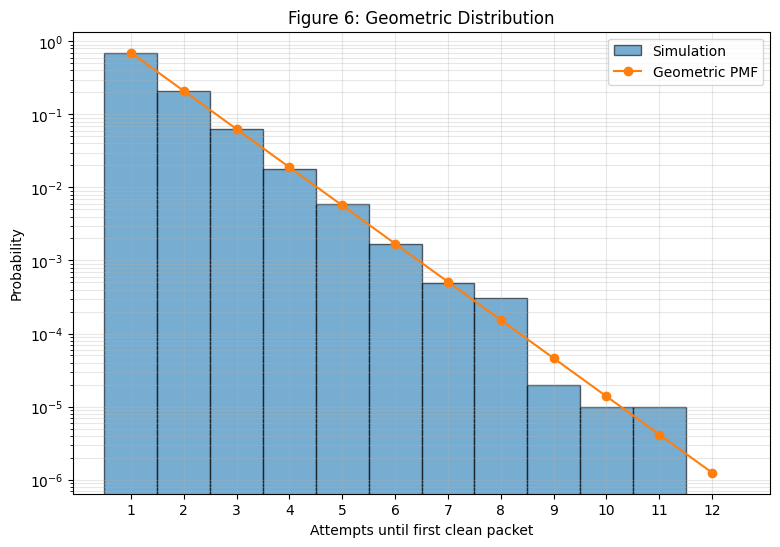


MEMORYLESS PROPERTY

(m, n) = (1, 2)
P(N > 3 | N > 1) = 0.08689 ± 0.00162
P(N > 2) = 0.08891 ± 0.00090
Difference = -0.00202 ± 0.00186

(m, n) = (3, 2)
P(N > 5 | N > 3) = 0.09549 ± 0.00574
P(N > 2) = 0.08891 ± 0.00090
Difference = 0.00658 ± 0.00581

(m, n) = (5, 2)
P(N > 7 | N > 5) = 0.14000 ± 0.02195
P(N > 2) = 0.08891 ± 0.00090
Difference = 0.05109 ± 0.02196


In [92]:
# STEP 6 - Retransmissions and the geometric distribution

print("The number of attempts until the first clean packet is geometrically distributed because")
print("each attempt is a Bernoulli trial with two outcomes: clean or not clean, and we count the")
print("attempts until the first clean packet. The key assumption is that packet outcomes are")
print("independent across attempts and have the same clean probability q on every attempt.")
print()

# Parameters
q = 0.7
num_sequences = 10**5

# Simulate attempts until the first clean packet
samples = attempts_until_clean(
    num_sequences,
    q,
    rng_step6
)

# Mean and variance
sample_mean = np.mean(samples)
sample_variance = np.var(samples, ddof=1)

theoretical_mean = 1 / q
theoretical_variance = (1 - q) / q**2

print("MEAN AND VARIANCE")
print(f"Sample mean:       {sample_mean:.5f}")
print(f"Theoretical mean:  {theoretical_mean:.5f}")
print(f"Sample variance:   {sample_variance:.5f}")
print(f"Theoretical var:   {theoretical_variance:.5f}")


# Histogram + geometric PMF
max_attempts = 12

bins = np.arange(0.5, max_attempts + 1.5, 1)

plt.figure(figsize=(9, 6))

plt.hist(
    samples,
    bins=bins,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Simulation"
)

n = np.arange(1, max_attempts + 1)
pmf = q * (1 - q)**(n - 1)

plt.plot(
    n,
    pmf,
    "o-",
    label="Geometric PMF"
)

plt.yscale("log")
plt.xlabel("Attempts until first clean packet")
plt.ylabel("Probability")
plt.title("Figure 6: Geometric Distribution")
plt.xticks(n)
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()


# Memoryless property
pairs = [(1, 2), (3, 2), (5, 2)]

print()
print("MEMORYLESS PROPERTY")

for m, n in pairs:

    conditional_samples = samples[samples > m]

    p_cond = np.mean(conditional_samples > m + n)

    se_cond = np.sqrt(
        p_cond * (1 - p_cond) / len(conditional_samples)
    )

    p_uncond = np.mean(samples > n)

    se_uncond = np.sqrt(
        p_uncond * (1 - p_uncond) / len(samples)
    )

    difference = p_cond - p_uncond

    se_difference = np.sqrt(
        se_cond**2 + se_uncond**2
    )

    print(f"\n(m, n) = ({m}, {n})")

    print(
        f"P(N > {m+n} | N > {m}) = "
        f"{p_cond:.5f} ± {se_cond:.5f}"
    )

    print(
        f"P(N > {n}) = "
        f"{p_uncond:.5f} ± {se_uncond:.5f}"
    )

    print(
        f"Difference = "
        f"{difference:.5f} ± {se_difference:.5f}"
    )

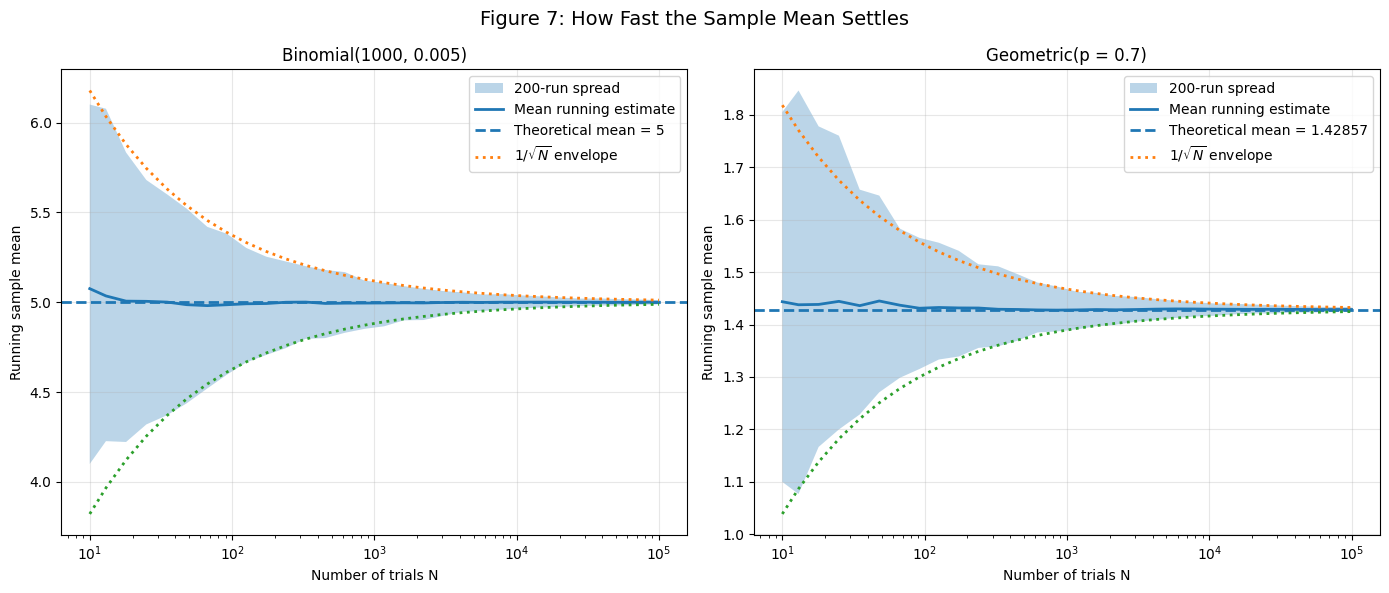

STEP 7 RESULTS

Binomial theoretical mean: 5.0
Binomial theoretical variance: 4.975

Geometric theoretical mean: 1.4285714285714286
Geometric theoretical variance: 0.6122448979591838

1% of the Binomial true mean: 0.05
Target interval: 4.95 to 5.05

Trials needed for the entire 200-run spread band to be within 1%:
5736

Observed spread at that N:
4.950880404463041 to 5.042721408647141


In [93]:

#STEP 7 -  Expectation, variance, and how fast estimates settle


import numpy as np
import matplotlib.pyplot as plt

# Random number generator
rng = np.random.default_rng(42)



# About 30 log-spaced checkpoints from 10 to 100,000
N_values = np.unique(np.logspace(1, 5, 30).astype(int))

# Number of independent experiments
num_runs = 200

# Largest number of trials
N_max = N_values[-1]


# THEORETICAL VALUES

# Binomial: X ~ Binomial(1000, 0.005)
binom_n = 1000
binom_p = 0.005
binom_theory = binom_n * binom_p
binom_variance = binom_n * binom_p * (1 - binom_p)

# Geometric: p = 0.7
# Counts number of attempts until first success
geom_p = 0.7
geom_theory = 1 / geom_p
geom_variance = (1 - geom_p) / (geom_p ** 2)


# STORAGE
# Only 200 x 30 values are stored

binom_means = np.zeros((num_runs, len(N_values)))
geom_means = np.zeros((num_runs, len(N_values)))

# RUN 200 INDEPENDENT EXPERIMENTS


for run in range(num_runs):

    
    # Binomial
    
    binom_samples = rng_step7.binomial(
        binom_n,
        binom_p,
        size=N_max
    )

    binom_cumsum = np.cumsum(binom_samples)

    binom_means[run, :] = (
        binom_cumsum[N_values - 1] / N_values
    )

    
    # Geometric
    
    geom_samples = rng_step7.geometric(
        geom_p,
        size=N_max
    )

    geom_cumsum = np.cumsum(geom_samples)

    geom_means[run, :] = (
        geom_cumsum[N_values - 1] / N_values
    )



# CALCULATE 200-RUN SPREAD
# Using the 5th and 95th percentiles


binom_low = np.percentile(
    binom_means,
    5,
    axis=0
)

binom_high = np.percentile(
    binom_means,
    95,
    axis=0
)

geom_low = np.percentile(
    geom_means,
    5,
    axis=0
)

geom_high = np.percentile(
    geom_means,
    95,
    axis=0
)


# Mean of the 200 running estimates
binom_center = np.mean(
    binom_means,
    axis=0
)

geom_center = np.mean(
    geom_means,
    axis=0
)



# 1 / sqrt(N) ENVELOPE
# Match the envelope to the observed band at one checkpoint


# Pick a middle checkpoint
match_idx = 10

# Binomial band half-width
binom_half_width = (
    binom_high[match_idx]
    - binom_low[match_idx]
) / 2

# Geometric band half-width
geom_half_width = (
    geom_high[match_idx]
    - geom_low[match_idx]
) / 2

# Constants so that envelope matches observed spread
binom_C = (
    binom_half_width
    * np.sqrt(N_values[match_idx])
)

geom_C = (
    geom_half_width
    * np.sqrt(N_values[match_idx])
)

# 1/sqrt(N) envelopes
binom_envelope = (
    binom_C / np.sqrt(N_values)
)

geom_envelope = (
    geom_C / np.sqrt(N_values)
)



# FIGURE 7


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)



# LEFT PANEL: BINOMIAL


ax = axes[0]

# Shaded 200-run spread
ax.fill_between(
    N_values,
    binom_low,
    binom_high,
    alpha=0.3,
    label="200-run spread"
)

# Average running sample mean
ax.plot(
    N_values,
    binom_center,
    linewidth=2,
    label="Mean running estimate"
)

# Theoretical mean
ax.axhline(
    binom_theory,
    linestyle="--",
    linewidth=2,
    label="Theoretical mean = 5"
)

# Upper 1/sqrt(N) envelope
ax.plot(
    N_values,
    binom_theory + binom_envelope,
    linestyle=":",
    linewidth=2,
    label=r"$1/\sqrt{N}$ envelope"
)

# Lower 1/sqrt(N) envelope
ax.plot(
    N_values,
    binom_theory - binom_envelope,
    linestyle=":",
    linewidth=2
)

ax.set_xscale("log")

ax.set_xlabel(
    "Number of trials N"
)

ax.set_ylabel(
    "Running sample mean"
)

ax.set_title(
    "Binomial(1000, 0.005)"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()



# RIGHT PANEL: GEOMETRIC


ax = axes[1]

# Shaded 200-run spread
ax.fill_between(
    N_values,
    geom_low,
    geom_high,
    alpha=0.3,
    label="200-run spread"
)

# Average running sample mean
ax.plot(
    N_values,
    geom_center,
    linewidth=2,
    label="Mean running estimate"
)

# Theoretical mean
ax.axhline(
    geom_theory,
    linestyle="--",
    linewidth=2,
    label=f"Theoretical mean = {geom_theory:.5f}"
)

# Upper 1/sqrt(N) envelope
ax.plot(
    N_values,
    geom_theory + geom_envelope,
    linestyle=":",
    linewidth=2,
    label=r"$1/\sqrt{N}$ envelope"
)

# Lower 1/sqrt(N) envelope
ax.plot(
    N_values,
    geom_theory - geom_envelope,
    linestyle=":",
    linewidth=2
)

ax.set_xscale("log")

ax.set_xlabel(
    "Number of trials N"
)

ax.set_ylabel(
    "Running sample mean"
)

ax.set_title(
    "Geometric(p = 0.7)"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()


# Overall title
plt.suptitle(
    "Figure 7: How Fast the Sample Mean Settles",
    fontsize=14
)

plt.tight_layout()

plt.show()



# BINOMIAL: HOW MANY TRIALS FOR WITHIN 1%?


# 1% of the true mean
tolerance = 0.01 * binom_theory

lower_target = binom_theory - tolerance
upper_target = binom_theory + tolerance

# Find checkpoints where the ENTIRE spread band
# is within the +/- 1% interval
within_1_percent = (
    (binom_low >= lower_target)
    &
    (binom_high <= upper_target)
)


print("STEP 7 RESULTS")

print()
print("Binomial theoretical mean:", binom_theory)
print("Binomial theoretical variance:", binom_variance)

print()
print("Geometric theoretical mean:", geom_theory)
print("Geometric theoretical variance:", geom_variance)

print()
print("1% of the Binomial true mean:", tolerance)
print(
    "Target interval:",
    lower_target,
    "to",
    upper_target
)

if np.any(within_1_percent):

    first_idx = np.where(
        within_1_percent
    )[0][0]

    needed_N = N_values[first_idx]

    print()
    print(
        "Trials needed for the entire 200-run",
        "spread band to be within 1%:"
    )
    print(needed_N)

    print()
    print(
        "Observed spread at that N:"
    )
    print(
        binom_low[first_idx],
        "to",
        binom_high[first_idx]
    )

else:

    print()
    print(
        "The 200-run spread band did not fit",
        "within 1% by N =",
        N_values[-1]
    )

STEP 8 RESULTS
p for E[T] = 2: 0.00069290701
p for 90% goodput: 0.00010535497


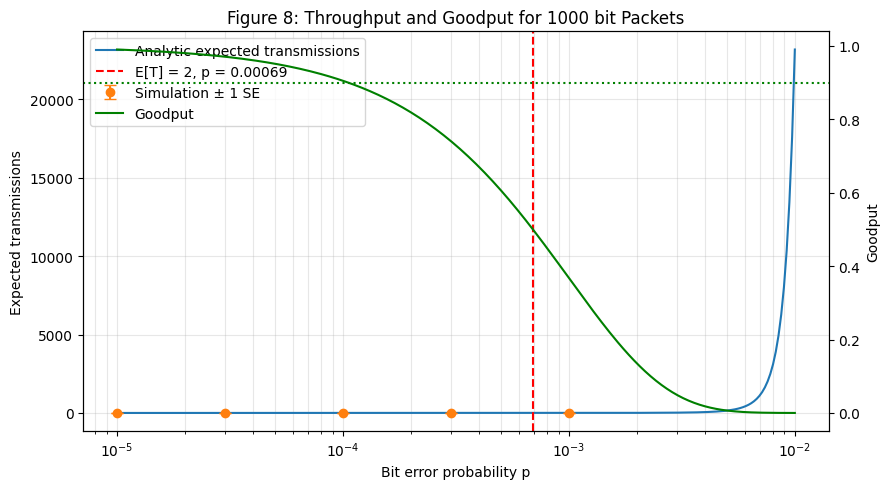

Figure 8 interpretation: The analytic curve is valid through p = 0.01 because each retransmission is an independent trial with the same clean probability.
During simulation the curve falls within their error bars and reaches the expected transmissions at p = 0.000693
The Goodput decreases as p increases because more transmissions are required and falls below 90 percent at p = 0.000105


In [94]:
#Step 8 - Throughput and Goodput

def clean_probability(p, packet_length):
    """
    Probability that every bit in a packet is correct.
    """
    return np.exp(packet_length * np.log1p(-np.asarray(p)))


packet_length = 1000
p_grid = np.logspace(-5, -2, 250)
q_grid = clean_probability(p_grid, packet_length)
expected_transmissions = 1 / q_grid
goodput = q_grid


# Simulated points, limited to p <= 10^-3
p_sim = np.array([
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3
])

n_sim = 20_000

simulated_means = []
simulated_standard_errors = []

for p_value in p_sim:
    q_value = float(clean_probability(p_value, packet_length))

    attempts = attempts_until_clean(
        n_sim,
        q_value,
        rng_step8
    )

    simulated_means.append(attempts.mean())

    simulated_standard_errors.append(
        attempts.std(ddof=1) / np.sqrt(n_sim)
    )

simulated_means = np.array(simulated_means)
simulated_standard_errors = np.array(simulated_standard_errors)


# Analytic thresholds
p_two_transmissions = 1 - 2 ** (-1 / packet_length)
p_ninety_percent_goodput = (1 - 0.90 ** (1 / packet_length))


print("STEP 8 RESULTS")
print(f"p for E[T] = 2: {p_two_transmissions:.8g}")
print(f"p for 90% goodput: {p_ninety_percent_goodput:.8g}")


# Figure 8
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    p_grid,
    expected_transmissions,
    label="Analytic expected transmissions"
)

ax1.errorbar(
    p_sim,
    simulated_means,
    yerr=simulated_standard_errors,
    fmt="o",
    capsize=4,
    label="Simulation ± 1 SE"
)

ax1.axvline(
    p_two_transmissions,
    color="red",
    linestyle="--",
    label=f"E[T] = 2, p = {p_two_transmissions:.2g}"
)

ax1.set_xscale("log")
ax1.set_xlabel("Bit error probability p")
ax1.set_ylabel("Expected transmissions")
ax1.set_title("Figure 8: Throughput and Goodput for 1000 bit Packets")
ax1.grid(True, which="both", alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    p_grid,
    goodput,
    color="green",
    label="Goodput"
)

ax2.axhline(
    0.90,
    color="green",
    linestyle=":"
)

ax2.set_ylabel("Goodput")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()


print("Figure 8 interpretation: The analytic curve is valid through p = 0.01 because each retransmission is an independent trial with the same clean probability.")
print("During simulation the curve falls within their error bars and reaches the expected transmissions at p = 0.000693")
print("The Goodput decreases as p increases because more transmissions are required and falls below 90 percent at p = 0.000105")



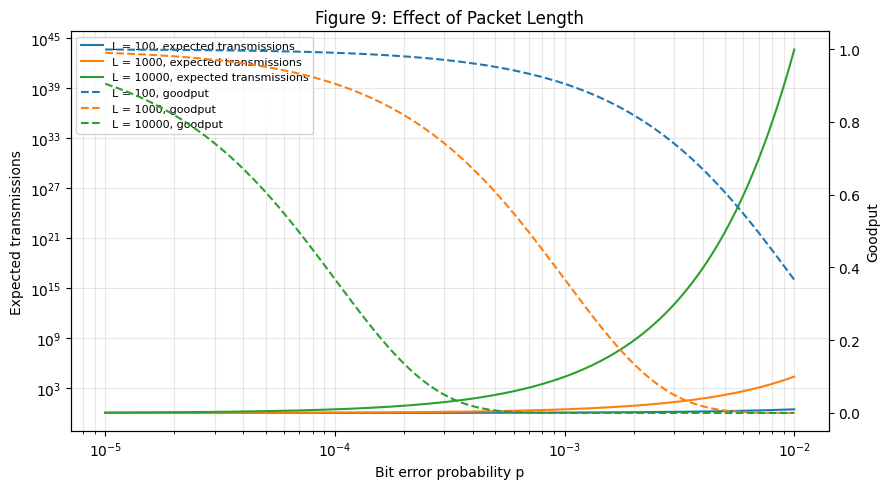

For 1000-bit packets, goodput remains above 90% only when p < 0.0001054.
Figure 9 interpretation: The effect on packet length that retransmissions and goodput have means that longer packets are less likley to be corrupted
The 10,000 bit packet requires retransmissions sooner and its Goodput decreases faster than the 100 and 1,000 bit packets
The 100 bit maintains the highest Goodput over the course of the simulation because it has the least amount of chances for it to corrupt.


In [95]:
# figure 9 - Packet Length Comparison

packet_lengths = [100, 1000, 10000]

fig, ax1 = plt.subplots(figsize=(9, 5))

for L in packet_lengths:
    q_L = clean_probability(p_grid, L)

    ax1.plot(
        p_grid,
        1 / q_L,
        label=f"L = {L}, expected transmissions"
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Bit error probability p")
ax1.set_ylabel("Expected transmissions")
ax1.set_title("Figure 9: Effect of Packet Length")
ax1.grid(True, which="both", alpha=0.3)

ax2 = ax1.twinx()

for L in packet_lengths:
    q_L = clean_probability(p_grid, L)

    ax2.plot(
        p_grid,
        q_L,
        linestyle="--",
        label=f"L = {L}, goodput"
    )

ax2.set_ylabel("Goodput")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=8,
    loc="upper left"
)

plt.tight_layout()
plt.show()

print(
    f"For 1000-bit packets, goodput remains above 90% only when "
    f"p < {p_ninety_percent_goodput:.4g}."
)

print("Figure 9 interpretation: The effect on packet length that retransmissions and goodput have means that longer packets are less likley to be corrupted")
print("The 10,000 bit packet requires retransmissions sooner and its Goodput decreases faster than the 100 and 1,000 bit packets")
print("The 100 bit maintains the highest Goodput over the course of the simulation because it has the least amount of chances for it to corrupt.")


In [96]:
# Bonus A - Tail Probability

p_bonus_a = 1e-4
L_bonus_a = 1000

q_bonus_a = float(
    clean_probability(p_bonus_a, L_bonus_a)
)

k_values = np.array([1, 2, 5, 10, 20])

n_bonus_a = 100_000

bonus_attempts = attempts_until_clean(
    n_bonus_a,
    q_bonus_a,
    rng_bonus
)

exact_tail = (1 - q_bonus_a) ** k_values

simulated_tail = np.array([
    np.mean(bonus_attempts > k)
    for k in k_values
])

# Union bound:
# P(at least one failed attempt in first k attempts)
union_bound = np.minimum(
    1,
    k_values * (1 - q_bonus_a)
)

bonus_a_table = pd.DataFrame({
    "k": k_values,
    "Exact P(N > k)": exact_tail,
    "Simulated P(N > k)": simulated_tail,
    "Union bound": union_bound
})

display(bonus_a_table)

print("The exact probability is (1-q)^k because all first k attempts must fail.")
print("The union bound is loose because it adds the probabilities of individual failures instead of requiring all failures simultaneously.")

,k,Exact P(N > k),Simulated P(N > k),Union bound
0,1,9.516711e-02,0.09687,0.095167
1,2,9.056778e-03,0.00890,0.190334
2,5,7.806104e-06,0.00000,0.475836
3,10,6.093526e-11,0.00000,0.951671
4,20,3.713106e-21,0.00000,1.000000


The exact probability is (1-q)^k because all first k attempts must fail.
The union bound is loose because it adds the probabilities of individual failures instead of requiring all failures simultaneously.


BONUS B RESULTS
----------------------------
Derivative optimum: 652.756 bits
Best integer length: 653 bits
Analytic goodput: 0.879400
Simulated goodput: 0.879682


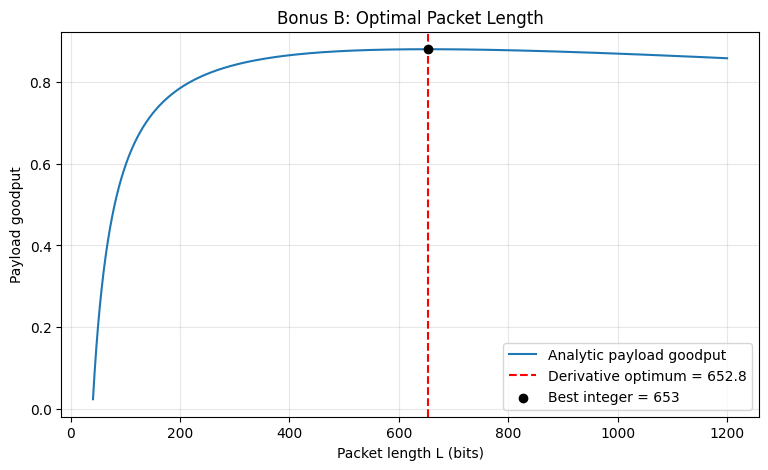

Figure Bonus B interpretation: The idea packet length is found to be about 653 bits.
Shorter packets loose a large fraction of their bits on overhead, which reduces the payload Goodput.
Longer packets carry more playload but are more likely to contain an error that would require another transmission.


In [97]:
# Bonus B - Optimal Packet Length

p_bonus_b = 1e-4
header_bits = 40

def payload_goodput(packet_length):
    """
    Payload goodput with a fixed 40-bit header.
    """
    return (
        (packet_length - header_bits)
        / packet_length
        * clean_probability(p_bonus_b, packet_length)
    )


# Derivative of log goodput:
# d/dL log(G) = 40 / [L(L - 40)] + log(1-p)
# Set equal to zero.

def derivative_condition(packet_length):
    return (
        header_bits / (packet_length * (packet_length - header_bits)) + np.log1p(-p_bonus_b)
    )


continuous_optimum = brentq(
    derivative_condition,
    header_bits + 1e-6,
    100_000
)


integer_lengths = np.arange(header_bits + 1, 2001)

integer_goodputs = payload_goodput(integer_lengths)

best_integer_index = np.argmax(integer_goodputs)

best_integer_length = integer_lengths[best_integer_index]

best_integer_goodput = integer_goodputs[best_integer_index]


# Confirm by simulation
q_best = float(
    clean_probability(p_bonus_b, best_integer_length)
)

simulation_attempts = attempts_until_clean(
    100_000,
    q_best,
    rng_bonus
)

simulated_goodput = (
    (best_integer_length - header_bits)
    * len(simulation_attempts)
    /
    (
        best_integer_length
        * simulation_attempts.sum()
    )
)


print("BONUS B RESULTS")
print("----------------------------")
print(f"Derivative optimum: {continuous_optimum:.3f} bits")
print(f"Best integer length: {best_integer_length} bits")
print(f"Analytic goodput: {best_integer_goodput:.6f}")
print(f"Simulated goodput: {simulated_goodput:.6f}")


# Plot the objective
length_grid = np.arange(41, 1201)

plt.figure(figsize=(9, 5))

plt.plot(
    length_grid,
    payload_goodput(length_grid),
    label="Analytic payload goodput"
)

plt.axvline(
    continuous_optimum,
    color="red",
    linestyle="--",
    label=f"Derivative optimum = {continuous_optimum:.1f}"
)

plt.scatter(
    [best_integer_length],
    [best_integer_goodput],
    color="black",
    zorder=3,
    label=f"Best integer = {best_integer_length}"
)

plt.xlabel("Packet length L (bits)")
plt.ylabel("Payload goodput")
plt.title("Bonus B: Optimal Packet Length")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Figure Bonus B interpretation: The idea packet length is found to be about 653 bits.")
print("Shorter packets loose a large fraction of their bits on overhead, which reduces the payload Goodput.")
print("Longer packets carry more playload but are more likely to contain an error that would require another transmission.")
